# Notebook 1 — Exercise 1: Fraud Detection (Knowledge Distillation)

> **Story context:** CompanyX has a large fraud detection model (BigModel) that is expensive to run at inference time. They hire us to build a TinyModel that matches BigModel's performance at a fraction of the cost.
> 
> This is **Knowledge Distillation**: instead of training on binary labels (fraud/not fraud), we train on the *probabilities* produced by BigModel. The target column in `fraud_dataset.csv` is already these soft probabilities.

We reuse the perceptron implementations from Notebook 0.

**Roadmap:**
1. Explore the dataset (EDA)
2. Compare linear vs. non-linear perceptron
3. Select the best model and study generalization
4. Recommend a fraud detection threshold to CompanyX

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, average_precision_score

np.random.seed(42)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size'] = 11

# ── Reuse models from Notebook 0 ─────────────────────────────────────────────

class LinearPerceptron:
    def __init__(self, n_features, learning_rate=0.01, max_epochs=2000):
        self.lr = learning_rate; self.max_epochs = max_epochs
        self.w = np.random.uniform(-0.1, 0.1, size=n_features + 1)
        self.loss_history = []
    def _add_bias(self, X): return np.hstack([np.ones((X.shape[0], 1)), X])
    def predict(self, X):   return self._add_bias(X) @ self.w
    def fit(self, X, y, verbose_every=0):
        X_b = self._add_bias(X); p = X_b.shape[0]
        for epoch in range(self.max_epochs):
            idx = np.random.randint(p)
            o = X_b[idx] @ self.w
            self.w += self.lr * (y[idx] - o) * X_b[idx]
            sse = 0.5 * np.sum((y - X_b @ self.w)**2)
            self.loss_history.append(sse)
            if verbose_every and (epoch+1) % verbose_every == 0:
                print(f"  Epoch {epoch+1:5d} | SSE = {sse:.4f}")
        return self


class NonLinearPerceptron:
    ACTIVATIONS = {
        'tanh':    (lambda h, b: np.tanh(b*h),           lambda g, b: b*(1-g**2)),
        'sigmoid': (lambda h, b: 1/(1+np.exp(-2*b*h)),   lambda g, b: 2*b*g*(1-g)),
        'relu':    (lambda h, b: np.maximum(0, h),        lambda g, b: (g>0).astype(float)),
    }
    def __init__(self, n_features, learning_rate=0.01, max_epochs=3000,
                 activation='sigmoid', beta=1.0):
        self.lr = learning_rate; self.max_epochs = max_epochs; self.beta = beta
        self.activation_name = activation
        self.g, self.g_prime = self.ACTIVATIONS[activation]
        self.w = np.random.uniform(-0.1, 0.1, size=n_features + 1)
        self.loss_history = []
    def _add_bias(self, X): return np.hstack([np.ones((X.shape[0], 1)), X])
    def predict(self, X):
        h = self._add_bias(X) @ self.w
        return self.g(h, self.beta)
    def fit(self, X, y, verbose_every=0):
        X_b = self._add_bias(X); p = X_b.shape[0]
        for epoch in range(self.max_epochs):
            idx = np.random.randint(p)
            h = X_b[idx] @ self.w
            o = self.g(h, self.beta)
            grad = (y[idx] - o) * self.g_prime(o, self.beta)
            self.w += self.lr * grad * X_b[idx]
            preds = self.predict(X)
            self.loss_history.append(0.5 * np.sum((y - preds)**2))
            if verbose_every and (epoch+1) % verbose_every == 0:
                print(f"  Epoch {epoch+1:5d} | SSE = {self.loss_history[-1]:.4f}")
        return self

print("Models loaded.")

Models loaded.


---
## Step 1 — Exploratory Data Analysis (EDA)

> The professors strongly emphasized this: **understand the data before touching the models**.
> - What does each column represent?
> - What are the value ranges?
> - Is the data clean? Are there missing values or outliers?
> - What is the distribution of the target variable?

In [2]:
df = pd.read_csv('data and documentation/fraud_dataset.csv')
print(f"Shape: {df.shape}  ({df.shape[0]} samples, {df.shape[1]} columns)")
print(f"\nColumn types:")
print(df.dtypes)

Shape: (7500, 11)  (7500 samples, 11 columns)

Column types:
timestamp                         int64
amount_usd                      float64
quantity_purchased                int64
session_duration_seconds        float64
days_since_last_purchase        float64
account_age_days                  int64
device_screen_resolution          int64
time_since_last_login_s         float64
items_viewed_before_purchase      int64
big_model_fraud_probability     float64
flagged_fraud                     int64
dtype: object


In [3]:
print("First 5 rows:")
df.head()

First 5 rows:


,timestamp,amount_usd,quantity_purchased,session_duration_seconds,days_since_last_purchase,account_age_days,device_screen_resolution,time_since_last_login_s,items_viewed_before_purchase,big_model_fraud_probability,flagged_fraud
0,1726079771,42.07,5,422.6,1.61,830,8297586,1591.0,9,0.399304,0
1,1712136533,35.05,6,384.7,23.44,2993,3682826,4097.6,10,0.026173,0
2,1703558249,1.43,8,519.5,34.07,2354,1034996,2534.0,5,0.080938,0
3,1704576488,100.00,4,51.1,0.57,85,8297645,2458.9,23,0.926975,1
4,1728790505,51.51,1,278.0,5.31,1989,1044536,2774.4,12,0.281695,0


In [4]:
print("Descriptive statistics:")
df.describe()

Descriptive statistics:


,timestamp,amount_usd,quantity_purchased,session_duration_seconds,days_since_last_purchase,account_age_days,device_screen_resolution,time_since_last_login_s,items_viewed_before_purchase,big_model_fraud_probability,flagged_fraud
count,7.500000e+03,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7.500000e+03,7500.000000,7500.000000,7500.000000,7500.000000
mean,1.715784e+09,109.070793,5.855467,280.188627,13.703097,1664.799600,3.175686e+06,3589.362587,8.612933,0.422785,0.115867
std,9.162462e+06,157.746527,4.139798,135.957916,14.926759,1122.779268,2.682004e+06,3565.242908,5.396869,0.302472,0.320086
min,1.700002e+09,1.000000,1.000000,5.000000,0.000000,1.000000,1.006733e+06,10.000000,1.000000,0.000897,0.000000
25%,1.707865e+09,25.925000,3.000000,186.700000,3.167500,639.000000,1.045387e+06,1051.225000,4.000000,0.158705,0.000000
50%,1.715683e+09,63.490000,5.000000,287.000000,8.590000,1633.500000,2.073158e+06,2477.700000,8.000000,0.357341,0.000000
75%,1.723707e+09,127.287500,8.000000,376.325000,19.350000,2640.000000,3.689208e+06,5004.150000,12.000000,0.663265,0.000000
max,1.731534e+09,2000.000000,24.000000,726.800000,142.320000,3649.000000,8.310940e+06,40160.800000,29.000000,1.000000,1.000000


In [5]:
# Missing values check
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.any() else "  None — dataset is clean.")

Missing values per column:
  None — dataset is clean.


In [6]:
# Identify the target column (soft probability from BigModel)
# Adjust 'target' to the actual column name in your CSV
TARGET_COL = df.columns[-1]   # <-- update if needed
FEATURE_COLS = [c for c in df.columns if c != TARGET_COL]

print(f"Target column : '{TARGET_COL}'")
print(f"Feature columns: {FEATURE_COLS}")
print(f"\nTarget stats:")
print(df[TARGET_COL].describe())

Target column : 'flagged_fraud'
Feature columns: ['timestamp', 'amount_usd', 'quantity_purchased', 'session_duration_seconds', 'days_since_last_purchase', 'account_age_days', 'device_screen_resolution', 'time_since_last_login_s', 'items_viewed_before_purchase', 'big_model_fraud_probability']

Target stats:
count    7500.000000
mean        0.115867
std         0.320086
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: flagged_fraud, dtype: float64


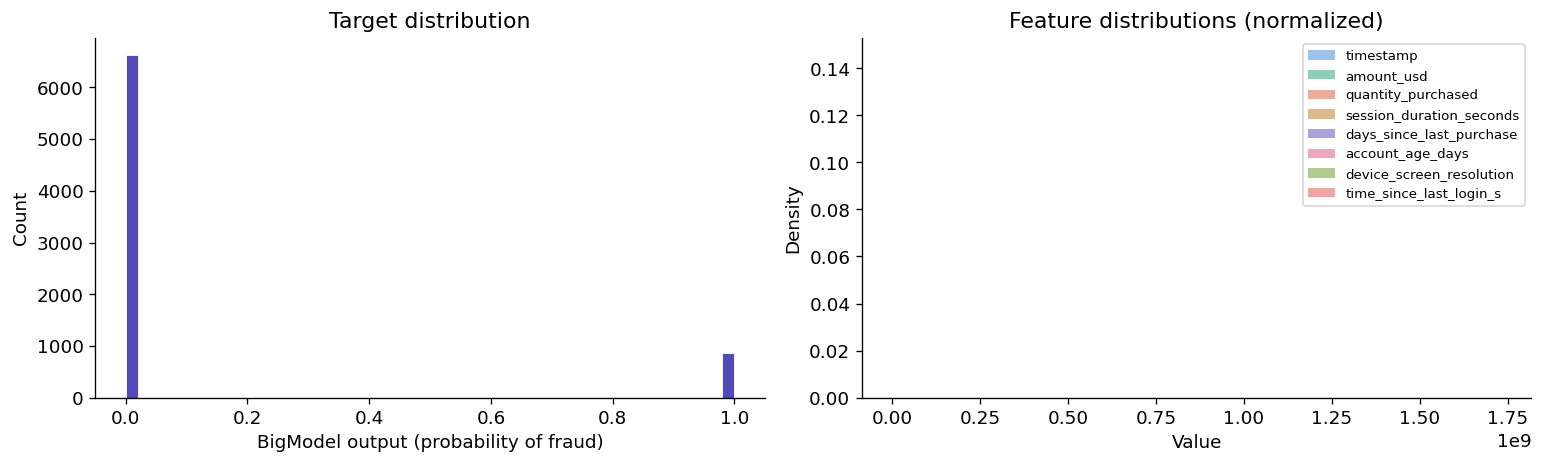

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Target distribution
axes[0].hist(df[TARGET_COL], bins=50, color='#534AB7', edgecolor='white', linewidth=0.5)
axes[0].set_xlabel(f'BigModel output (probability of fraud)')
axes[0].set_ylabel('Count')
axes[0].set_title('Target distribution')

# Feature distributions (select numeric columns)
numeric_feats = df[FEATURE_COLS].select_dtypes(include=np.number).columns
n_feats = min(len(numeric_feats), 8)
colors = ['#378ADD', '#1D9E75', '#D85A30', '#BA7517',
          '#534AB7', '#D4537E', '#639922', '#E24B4A']

ax2 = axes[1]
for i, col in enumerate(numeric_feats[:n_feats]):
    vals = df[col].dropna()
    ax2.hist(vals, bins=30, alpha=0.5, label=col, color=colors[i % len(colors)], density=True)
ax2.set_xlabel('Value'); ax2.set_ylabel('Density')
ax2.set_title('Feature distributions (normalized)')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('ex1_eda.png', bbox_inches='tight')
plt.show()

---
## Step 2 — Data Preprocessing & Normalization

Perceptrons are sensitive to feature scale — a feature with range [0, 10000] will dominate one with range [0, 1] during gradient descent. We standardize each feature to zero mean and unit variance:

$$x'_i = \frac{x_i - \mu_i}{\sigma_i}$$

**Important:** we compute $\mu$ and $\sigma$ on the **training set only** and apply them to the validation set, to avoid data leakage.

In [8]:
# Extract features and target
numeric_feats = df[FEATURE_COLS].select_dtypes(include=np.number).columns.tolist()
X_raw = df[numeric_feats].values.astype(float)
y_raw = df[TARGET_COL].values.astype(float)

print(f"Features used : {numeric_feats}")
print(f"X shape       : {X_raw.shape}")
print(f"y range       : [{y_raw.min():.3f}, {y_raw.max():.3f}]")

# Check if target is already in [0,1]
# For sigmoid output we need [0,1]; for tanh we could remap to [-1,1]
assert 0 <= y_raw.min() and y_raw.max() <= 1, \
    "Target should be a probability in [0,1]. Rescale if needed."
print("Target is in [0,1] — sigmoid activation is appropriate for TinyModel.")

Features used : ['timestamp', 'amount_usd', 'quantity_purchased', 'session_duration_seconds', 'days_since_last_purchase', 'account_age_days', 'device_screen_resolution', 'time_since_last_login_s', 'items_viewed_before_purchase', 'big_model_fraud_probability']
X shape       : (7500, 10)
y range       : [0.000, 1.000]
Target is in [0,1] — sigmoid activation is appropriate for TinyModel.


In [9]:
def standardize(X_train, X_val):
    """Standardize using training set statistics only."""
    mu    = X_train.mean(axis=0)
    sigma = X_train.std(axis=0) + 1e-8  # avoid division by zero
    return (X_train - mu) / sigma, (X_val - mu) / sigma, mu, sigma

# Full dataset standardized (for Step 3 learning capacity study)
mu_all   = X_raw.mean(axis=0)
sig_all  = X_raw.std(axis=0) + 1e-8
X_scaled = (X_raw - mu_all) / sig_all

print("Feature means after scaling (should be ~0):")
print(X_scaled.mean(axis=0).round(3))

Feature means after scaling (should be ~0):
[-0.  0.  0.  0. -0. -0.  0. -0. -0.  0.]


---
## Step 3 — Learning Capacity: Linear vs. Non-linear Perceptron

> We train both models on **all available data** (no train/test split yet).  
> This isolates **learning capacity** from **generalization** — we want to know what each model can theoretically achieve.

### What to look for:
- **Underfitting:** SSE stays high — the model cannot represent the relationship at all.
- **Saturation:** SSE plateaus quickly regardless of more training — the model has hit its expressive limit.
- **Good fit:** SSE decreases and stabilizes at a low value.

In [10]:
N_EPOCHS = 5000
LR_LINEAR = 0.001
LR_NONLIN = 0.01
n_feats = X_scaled.shape[1]

print("Training Linear Perceptron on full dataset...")
model_linear_full = LinearPerceptron(n_feats, learning_rate=LR_LINEAR, max_epochs=N_EPOCHS)
model_linear_full.fit(X_scaled, y_raw, verbose_every=1000)

print("\nTraining Non-linear Perceptron (sigmoid) on full dataset...")
model_nl_full = NonLinearPerceptron(n_feats, learning_rate=LR_NONLIN, max_epochs=N_EPOCHS,
                                     activation='sigmoid', beta=1.0)
model_nl_full.fit(X_scaled, y_raw, verbose_every=1000)

Training Linear Perceptron on full dataset...
  Epoch  1000 | SSE = 159.0210
  Epoch  2000 | SSE = 136.6008
  Epoch  3000 | SSE = 131.9935
  Epoch  4000 | SSE = 131.4658
  Epoch  5000 | SSE = 129.9205

Training Non-linear Perceptron (sigmoid) on full dataset...
  Epoch  1000 | SSE = 141.2544
  Epoch  2000 | SSE = 102.5834
  Epoch  3000 | SSE = 88.5151
  Epoch  4000 | SSE = 81.7183
  Epoch  5000 | SSE = 75.7892


In [11]:
preds_lin_full = np.clip(model_linear_full.predict(X_scaled), 0, 1)
preds_nl_full  = model_nl_full.predict(X_scaled)

mse_lin = np.mean((y_raw - preds_lin_full)**2)
mse_nl  = np.mean((y_raw - preds_nl_full)**2)

print(f"Linear    MSE (full data): {mse_lin:.5f}")
print(f"Non-linear MSE (full data): {mse_nl:.5f}")

Linear    MSE (full data): 0.02919
Non-linear MSE (full data): 0.02021


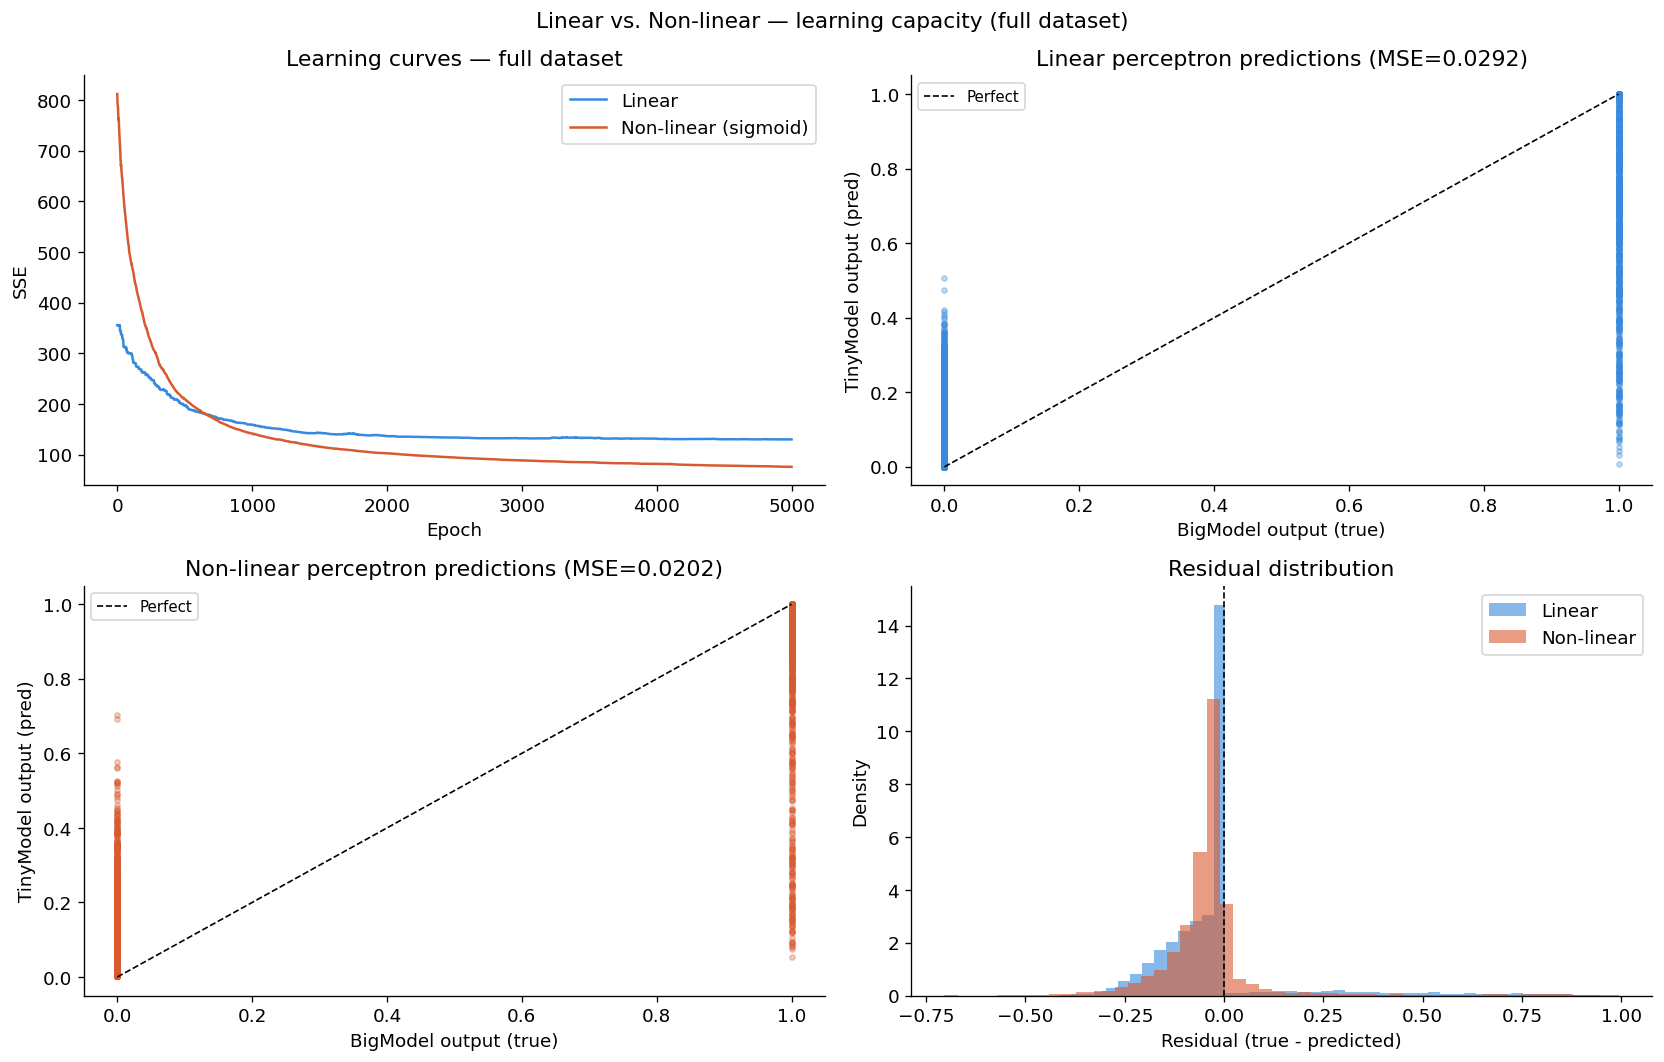

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Loss curves
ax = axes[0, 0]
ax.plot(model_linear_full.loss_history, color='#378ADD', lw=1.5, label='Linear')
ax.plot(model_nl_full.loss_history, color='#D85A30', lw=1.5, label='Non-linear (sigmoid)')
ax.set_xlabel('Epoch'); ax.set_ylabel('SSE')
ax.set_title('Learning curves — full dataset')
ax.legend()

# Prediction scatter — linear
ax2 = axes[0, 1]
ax2.scatter(y_raw, preds_lin_full, alpha=0.3, s=10, color='#378ADD')
ax2.plot([0,1],[0,1], 'k--', lw=1, label='Perfect')
ax2.set_xlabel('BigModel output (true)'); ax2.set_ylabel('TinyModel output (pred)')
ax2.set_title(f'Linear perceptron predictions (MSE={mse_lin:.4f})')
ax2.legend(fontsize=9)

# Prediction scatter — non-linear
ax3 = axes[1, 0]
ax3.scatter(y_raw, preds_nl_full, alpha=0.3, s=10, color='#D85A30')
ax3.plot([0,1],[0,1], 'k--', lw=1, label='Perfect')
ax3.set_xlabel('BigModel output (true)'); ax3.set_ylabel('TinyModel output (pred)')
ax3.set_title(f'Non-linear perceptron predictions (MSE={mse_nl:.4f})')
ax3.legend(fontsize=9)

# Residuals
ax4 = axes[1, 1]
ax4.hist(y_raw - preds_lin_full, bins=50, alpha=0.6, color='#378ADD', label='Linear', density=True)
ax4.hist(y_raw - preds_nl_full,  bins=50, alpha=0.6, color='#D85A30', label='Non-linear', density=True)
ax4.axvline(0, color='k', lw=1, ls='--')
ax4.set_xlabel('Residual (true - predicted)'); ax4.set_ylabel('Density')
ax4.set_title('Residual distribution')
ax4.legend()

plt.suptitle('Linear vs. Non-linear — learning capacity (full dataset)', fontsize=13)
plt.tight_layout()
plt.savefig('ex1_capacity.png', bbox_inches='tight')
plt.show()

### Discussion — Learning Capacity

**a) Underfitting?**  
The **linear perceptron** is likely to underfit: it can only model a linear relationship between the features and the fraud probability. Since fraud detection is inherently non-linear (complex interaction between features), a single hyperplane is insufficient.

**b) Saturation?**  
The **non-linear perceptron** with sigmoid activation can produce outputs in (0, 1) naturally matching the target range. Its learning curve should reach a lower SSE plateau, but it is still a **single-neuron model** — it learns one weighted combination of features + a non-linearity. It cannot model feature interactions.

**c) Which to select for generalization?**  
We select the **non-linear perceptron** for the generalization study, because:
1. Its output range (0, 1) matches the probability target natively.
2. It achieves a lower MSE on the full dataset.
3. The linear model's predictions may fall outside [0, 1], making threshold selection meaningless.

---
## Step 4 — Generalization Study

### Evaluation metrics

For a **fraud detection** problem, we choose:

| Metric | Why |
|---|---|
| **MSE** | Direct measure of how well we distill BigModel's probabilities |
| **ROC-AUC** | Measures ranking ability across all thresholds — threshold-independent |
| **Average Precision (PR-AUC)** | Better than ROC-AUC when classes are imbalanced (fraud is rare) |
| **Precision / Recall @ threshold** | Client needs to choose a threshold — we study the trade-off |

We do **not** use plain accuracy because fraud datasets are typically imbalanced — predicting "not fraud" always would give high accuracy but be useless.

### Strategy: k-Fold Cross-Validation

We use **5-fold cross-validation** to estimate generalization:
- Split the data into 5 folds
- Train on 4 folds, evaluate on 1, rotate 5 times
- Report mean ± std across folds

This gives a **statistically robust estimate** of performance without "wasting" data.

In [13]:
def k_fold_split(n, k=5, seed=42):
    """Returns list of (train_idx, val_idx) tuples for k-fold CV."""
    rng = np.random.default_rng(seed)
    idx = rng.permutation(n)
    folds = np.array_split(idx, k)
    splits = []
    for i in range(k):
        val   = folds[i]
        train = np.concatenate([folds[j] for j in range(k) if j != i])
        splits.append((train, val))
    return splits


def run_cv(X, y, model_class, model_kwargs, k=5, seed=42, verbose=True):
    """Run k-fold CV for a given model class. Returns per-fold metrics."""
    splits = k_fold_split(len(y), k=k, seed=seed)
    results = []

    for fold, (train_idx, val_idx) in enumerate(splits):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]

        # Standardize using training set only
        X_tr_s, X_val_s, _, _ = standardize(X_tr, X_val)

        model = model_class(**model_kwargs)
        model.fit(X_tr_s, y_tr)
        preds = model.predict(X_val_s)
        preds = np.clip(preds, 0, 1)

        mse  = np.mean((y_val - preds)**2)
        auc  = roc_auc_score(y_val > 0.5, preds)  # binarize for AUC
        ap   = average_precision_score(y_val > 0.5, preds)

        results.append({'fold': fold+1, 'mse': mse, 'auc': auc, 'ap': ap,
                        'preds': preds, 'y_val': y_val})
        if verbose:
            print(f"  Fold {fold+1}: MSE={mse:.4f} | AUC={auc:.4f} | AP={ap:.4f}")

    mses  = [r['mse'] for r in results]
    aucs  = [r['auc'] for r in results]
    aps   = [r['ap']  for r in results]
    print(f"\n  Mean MSE : {np.mean(mses):.4f} ± {np.std(mses):.4f}")
    print(f"  Mean AUC : {np.mean(aucs):.4f} ± {np.std(aucs):.4f}")
    print(f"  Mean AP  : {np.mean(aps):.4f} ± {np.std(aps):.4f}")
    return results

In [14]:
print("=" * 50)
print("5-Fold CV — Non-linear Perceptron (sigmoid)")
print("=" * 50)

nl_cv_results = run_cv(
    X_raw, y_raw,
    model_class=NonLinearPerceptron,
    model_kwargs=dict(n_features=X_raw.shape[1], learning_rate=0.01,
                      max_epochs=5000, activation='sigmoid', beta=1.0),
    k=5
)

5-Fold CV — Non-linear Perceptron (sigmoid)
  Fold 1: MSE=0.0200 | AUC=0.9951 | AP=0.9760
  Fold 2: MSE=0.0186 | AUC=0.9949 | AP=0.9721
  Fold 3: MSE=0.0197 | AUC=0.9935 | AP=0.9654
  Fold 4: MSE=0.0221 | AUC=0.9930 | AP=0.9674
  Fold 5: MSE=0.0247 | AUC=0.9879 | AP=0.9585

  Mean MSE : 0.0210 ± 0.0022
  Mean AUC : 0.9929 ± 0.0026
  Mean AP  : 0.9679 ± 0.0060


In [15]:
# Pool all out-of-fold predictions for overall ROC and PR curves
all_y    = np.concatenate([r['y_val'] for r in nl_cv_results])
all_pred = np.concatenate([r['preds'] for r in nl_cv_results])

y_binary = (all_y > 0.5).astype(int)

fpr, tpr, thresholds_roc = roc_curve(y_binary, all_pred)
precision, recall, thresholds_pr = precision_recall_curve(y_binary, all_pred)
overall_auc = roc_auc_score(y_binary, all_pred)
overall_ap  = average_precision_score(y_binary, all_pred)

print(f"Overall (pooled) ROC-AUC : {overall_auc:.4f}")
print(f"Overall (pooled) PR-AUC  : {overall_ap:.4f}")

Overall (pooled) ROC-AUC : 0.9921
Overall (pooled) PR-AUC  : 0.9648


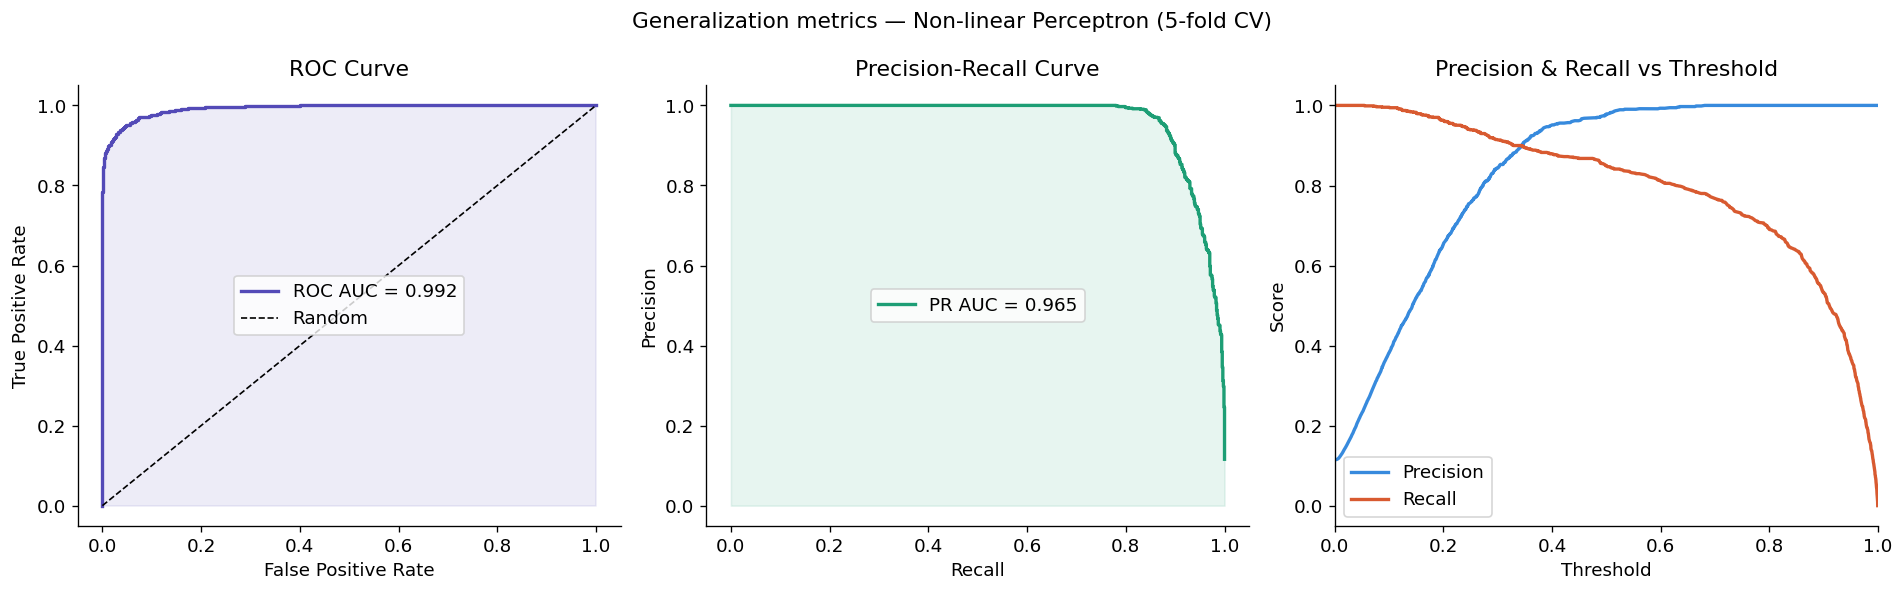

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ROC curve
ax = axes[0]
ax.plot(fpr, tpr, color='#534AB7', lw=2, label=f'ROC AUC = {overall_auc:.3f}')
ax.plot([0,1],[0,1], 'k--', lw=1, label='Random')
ax.fill_between(fpr, tpr, alpha=0.1, color='#534AB7')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve'); ax.legend()

# PR curve
ax2 = axes[1]
ax2.plot(recall, precision, color='#1D9E75', lw=2, label=f'PR AUC = {overall_ap:.3f}')
ax2.fill_between(recall, precision, alpha=0.1, color='#1D9E75')
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve'); ax2.legend()

# Precision & Recall vs threshold
ax3 = axes[2]
ax3.plot(thresholds_pr, precision[:-1], color='#378ADD', lw=2, label='Precision')
ax3.plot(thresholds_pr, recall[:-1],    color='#D85A30', lw=2, label='Recall')
ax3.set_xlabel('Threshold'); ax3.set_ylabel('Score')
ax3.set_title('Precision & Recall vs Threshold')
ax3.legend()
ax3.set_xlim(0, 1)

plt.suptitle('Generalization metrics — Non-linear Perceptron (5-fold CV)', fontsize=13)
plt.tight_layout()
plt.savefig('ex1_generalization.png', bbox_inches='tight')
plt.show()

---
## Step 5 — Threshold Recommendation for CompanyX

Our model outputs a **probability** in (0, 1). CompanyX needs to decide: above which probability do we flag a transaction as fraudulent?

**The trade-off:**
- **Low threshold:** catch more fraud (high recall) but generate many false alarms (low precision). Costly if each alert triggers a manual review.
- **High threshold:** fewer false alarms but miss more real fraud. Costly if the company bears fraud losses.

We recommend the threshold that maximizes the **F1-score** (harmonic mean of precision and recall), which balances both concerns. Depending on CompanyX's cost structure, they may shift this up or down.

In [17]:
# Compute F1 for each threshold from the PR curve
f1_scores = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-8)
best_idx  = np.argmax(f1_scores)
best_threshold = thresholds_pr[best_idx]
best_f1        = f1_scores[best_idx]
best_precision = precision[best_idx]
best_recall    = recall[best_idx]

print("=" * 45)
print(" Recommended threshold for CompanyX")
print("=" * 45)
print(f"  Threshold  : {best_threshold:.3f}")
print(f"  F1-score   : {best_f1:.3f}")
print(f"  Precision  : {best_precision:.3f}  (of flagged transactions, this % are real fraud)")
print(f"  Recall     : {best_recall:.3f}  (of real fraud, this % is caught)")

 Recommended threshold for CompanyX
  Threshold  : 0.475
  F1-score   : 0.916
  Precision  : 0.969  (of flagged transactions, this % are real fraud)
  Recall     : 0.868  (of real fraud, this % is caught)


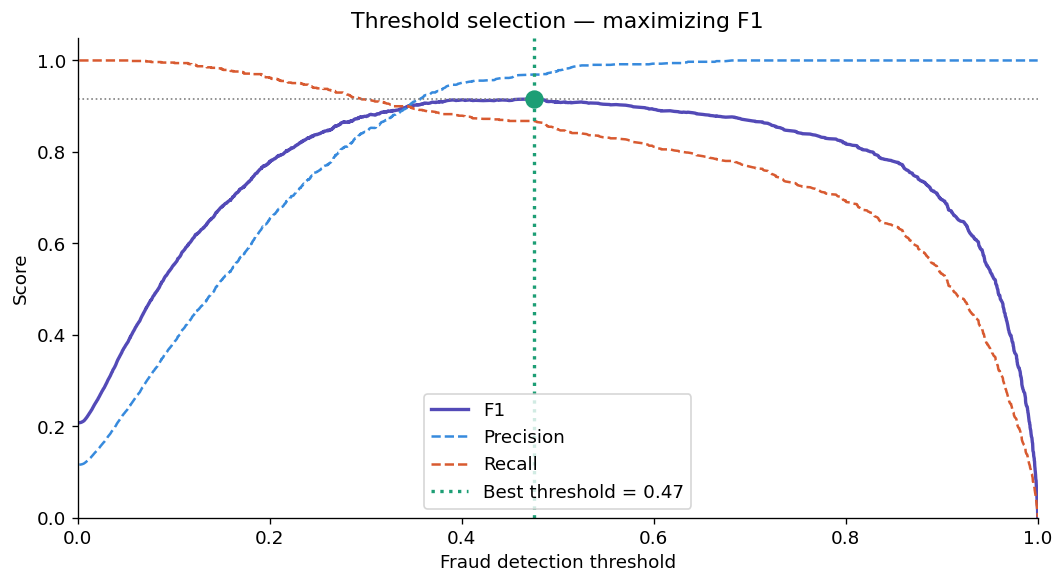


Recommendation to CompanyX:
  Flag transactions with probability > 0.47
  This catches 86.8% of fraud with 96.9% precision.
  If manual review cost is high, consider raising the threshold.
  If fraud losses are high, consider lowering it.


In [18]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(thresholds_pr, f1_scores,        color='#534AB7', lw=2,   label='F1')
ax.plot(thresholds_pr, precision[:-1],   color='#378ADD', lw=1.5, label='Precision', ls='--')
ax.plot(thresholds_pr, recall[:-1],      color='#D85A30', lw=1.5, label='Recall',    ls='--')
ax.axvline(best_threshold, color='#1D9E75', lw=2, ls=':', label=f'Best threshold = {best_threshold:.2f}')
ax.axhline(best_f1, color='gray', lw=1, ls=':')
ax.scatter([best_threshold], [best_f1], color='#1D9E75', s=100, zorder=5)

ax.set_xlabel('Fraud detection threshold')
ax.set_ylabel('Score')
ax.set_title('Threshold selection — maximizing F1')
ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
ax.legend()

plt.tight_layout()
plt.savefig('ex1_threshold.png', bbox_inches='tight')
plt.show()

print(f"\nRecommendation to CompanyX:")
print(f"  Flag transactions with probability > {best_threshold:.2f}")
print(f"  This catches {best_recall*100:.1f}% of fraud with {best_precision*100:.1f}% precision.")
print(f"  If manual review cost is high, consider raising the threshold.")
print(f"  If fraud losses are high, consider lowering it.")

In [ ]:
# ── Robustesse statistique — perceptron non-linéaire, N runs indépendants ─────

N_RUNS = 10
seeds  = [42, 123, 7, 99, 2024, 17, 303, 888, 1, 500]
run_results_ex1 = []

print(f"Running {N_RUNS} independent runs — Non-linear Perceptron")
print("=" * 55)

for i, seed in enumerate(seeds):
    np.random.seed(seed)
    print(f"\nRun {i+1}/{N_RUNS} (seed={seed})")
    
    # K-fold CV pour chaque run
    results = run_cv(
        X_raw, y_raw,
        model_class=NonLinearPerceptron,
        model_kwargs=dict(n_features=X_raw.shape[1], learning_rate=0.01,
                          max_epochs=5000, activation='sigmoid', beta=1.0),
        k=5,
        seed=seed,
        verbose=False
    )
    
    mean_mse = np.mean([r['mse'] for r in results])
    mean_auc = np.mean([r['auc'] for r in results])
    mean_ap  = np.mean([r['ap']  for r in results])
    
    run_results_ex1.append({
        'seed':     seed,
        'mse':      mean_mse,
        'auc':      mean_auc,
        'ap':       mean_ap,
    })
    print(f"  MSE={mean_mse:.4f} | AUC={mean_auc:.4f} | AP={mean_ap:.4f}")

# ── Statistiques globales ─────────────────────────────────────────────────────
mses = [r['mse'] for r in run_results_ex1]
aucs = [r['auc'] for r in run_results_ex1]
aps  = [r['ap']  for r in run_results_ex1]

print(f"\n{'='*55}")
print(f"  MSE : {np.mean(mses):.4f} ± {np.std(mses):.4f}")
print(f"  AUC : {np.mean(aucs):.4f} ± {np.std(aucs):.4f}")
print(f"  AP  : {np.mean(aps):.4f}  ± {np.std(aps):.4f}")
print(f"{'='*55}")

Running 10 independent runs — Non-linear Perceptron

Run 1/10 (seed=42)

  Mean MSE : 0.0207 ± 0.0022
  Mean AUC : 0.9932 ± 0.0020
  Mean AP  : 0.9686 ± 0.0038
  MSE=0.0207 | AUC=0.9932 | AP=0.9686

Run 2/10 (seed=123)

  Mean MSE : 0.0203 ± 0.0009
  Mean AUC : 0.9931 ± 0.0019
  Mean AP  : 0.9679 ± 0.0078
  MSE=0.0203 | AUC=0.9931 | AP=0.9679

Run 3/10 (seed=7)

  Mean MSE : 0.0203 ± 0.0021
  Mean AUC : 0.9935 ± 0.0019
  Mean AP  : 0.9686 ± 0.0079
  MSE=0.0203 | AUC=0.9935 | AP=0.9686

Run 4/10 (seed=99)

  Mean MSE : 0.0204 ± 0.0015
  Mean AUC : 0.9930 ± 0.0025
  Mean AP  : 0.9672 ± 0.0092
  MSE=0.0204 | AUC=0.9930 | AP=0.9672

Run 5/10 (seed=2024)

  Mean MSE : 0.0204 ± 0.0020
  Mean AUC : 0.9925 ± 0.0025
  Mean AP  : 0.9655 ± 0.0104
  MSE=0.0204 | AUC=0.9925 | AP=0.9655

  MSE : 0.0204 ± 0.0002
  AUC : 0.9930 ± 0.0003
  AP  : 0.9675  ± 0.0012


ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (10,) and arg 1 with shape (5,).

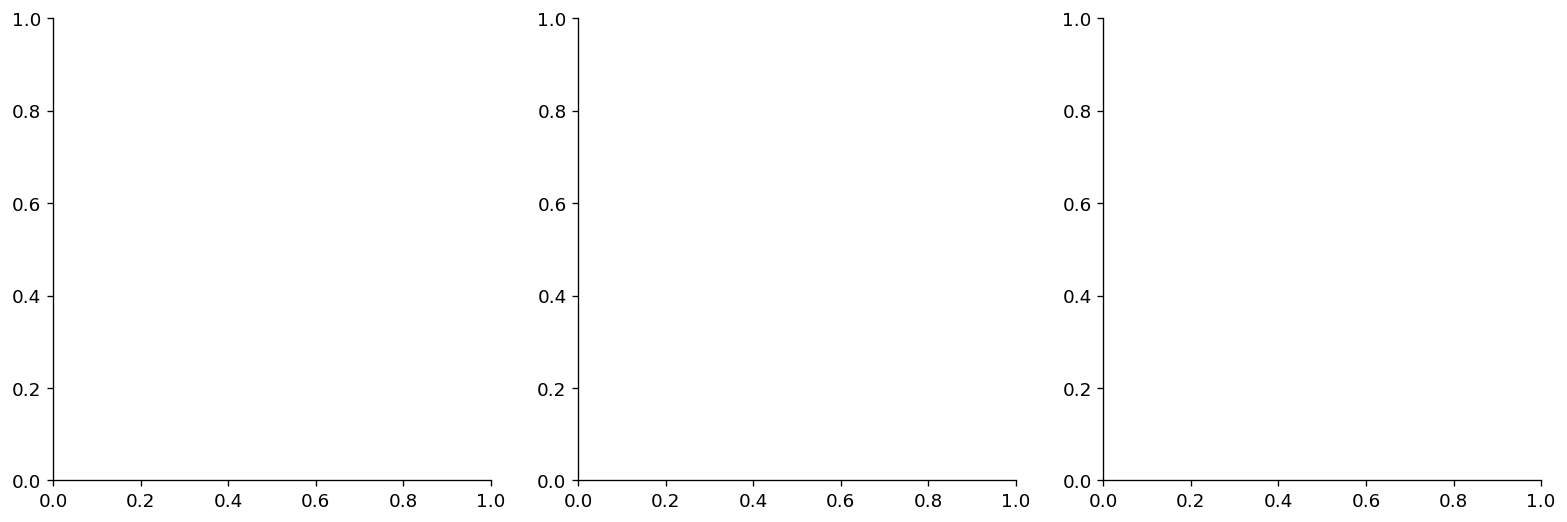

In [22]:
# ── Graphiques variance Ex1 ───────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = [
    ('mse', mses, 'MSE', '#534AB7'),
    ('auc', aucs, 'ROC-AUC', '#1D9E75'),
    ('ap',  aps,  'PR-AUC', '#D85A30'),
]

for ax, (key, vals, label, color) in zip(axes, metrics):
    vals_arr = np.array(vals)
    ax.bar(range(N_RUNS), vals_arr, color=color, alpha=0.8, edgecolor='white')
    ax.axhline(vals_arr.mean(), color='black', lw=2, ls='--',
               label=f'Mean = {vals_arr.mean():.4f}')
    ax.fill_between([-0.5, N_RUNS - 0.5],
                    vals_arr.mean() - vals_arr.std(),
                    vals_arr.mean() + vals_arr.std(),
                    alpha=0.15, color='black',
                    label=f'±1 std = {vals_arr.std():.4f}')
    ax.set_xticks(range(N_RUNS))
    ax.set_xticklabels([f'Run {i+1}\nseed={r["seed"]}' 
                        for i, r in enumerate(run_results_ex1)], fontsize=8)
    ax.set_ylabel(label)
    ax.set_title(f'{label} per run\n{vals_arr.mean():.4f} ± {vals_arr.std():.4f}')
    ax.legend(fontsize=8)

plt.suptitle('Statistical robustness — Non-linear Perceptron (5 runs × 5-fold CV)', 
             fontsize=13)
plt.tight_layout()
plt.savefig('ex1_variance.png', bbox_inches='tight')
plt.show()

---
## Summary — Exercise 1

| Question | Answer |
|---|---|
| **Underfitting?** | Linear perceptron underfits — cannot capture non-linear fraud signals |
| **Saturation?** | Non-linear is limited too (single neuron) but performs better |
| **Model selected** | Non-linear perceptron with sigmoid activation |
| **Metrics** | MSE (distillation quality), ROC-AUC, PR-AUC (imbalanced classes) |
| **Generalization strategy** | 5-fold cross-validation with train-only normalization |
| **Threshold recommendation** | Maximize F1 — balance between precision and recall |

> **Bridge to Exercise 2:** CompanyX was impressed with TinyModel for fraud, and now wants something more ambitious — classifying handwritten digits (0–9). A single perceptron has no chance here. We need the **Multilayer Perceptron** we validated on XOR in Notebook 0.